In [5]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

DATA_DIR = Path(r"C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\QTLab\RR Manual data")
DATA_FILE = DATA_DIR / "30cm_C1.bin"
HEADER_BYTES = 4096
SWEEP_START_NM = 1536.180
SWEEP_STOP_NM = 1562.978


def load_rr_binary(path, header_bytes=HEADER_BYTES):
    """Load the 16-bit ADC trace stored after the binary file header."""
    file_size = path.stat().st_size
    if file_size <= header_bytes:
        raise ValueError(f"File is smaller than the {header_bytes}-byte header: {path}")
    payload_bytes = file_size - header_bytes
    if payload_bytes % 2:
        raise ValueError("Payload length is not divisible by two; 16-bit decoding is invalid.")

    samples = np.fromfile(path, dtype="<u2", offset=header_bytes).astype(np.float64)
    if samples.size == 0 or not np.isfinite(samples).all():
        raise ValueError("No finite ADC samples were found.")
    return samples


samples = load_rr_binary(DATA_FILE)
wavelength_nm = np.linspace(SWEEP_START_NM, SWEEP_STOP_NM, samples.size)

# Keep the ADC counts and a dimensionless trace; absolute detector calibration is not in the file.
transmission = samples / np.median(samples)

print(f"Loaded {samples.size:,} samples from {DATA_FILE.name}")
print(f"Wavelength span: {wavelength_nm[0]:.3f} to {wavelength_nm[-1]:.3f} nm")
print(f"ADC counts: {samples.min():.0f} to {samples.max():.0f}")
print(f"Normalized transmission: {transmission.min():.4f} to {transmission.max():.4f}")

Loaded 10,000,000 samples from 30cm_C1.bin
Wavelength span: 1536.180 to 1562.978 nm
ADC counts: 11040 to 65535
Normalized transmission: 0.4432 to 2.6307


Analysis range: 1550.000 to 1550.200 nm
Smoothing window: 7,463 samples (0.02000 nm)
Detected 2 minima and 1 maxima
Median FSR: 0.10805 nm
Estimated optical path difference for n_g=1.468: 15.149 mm


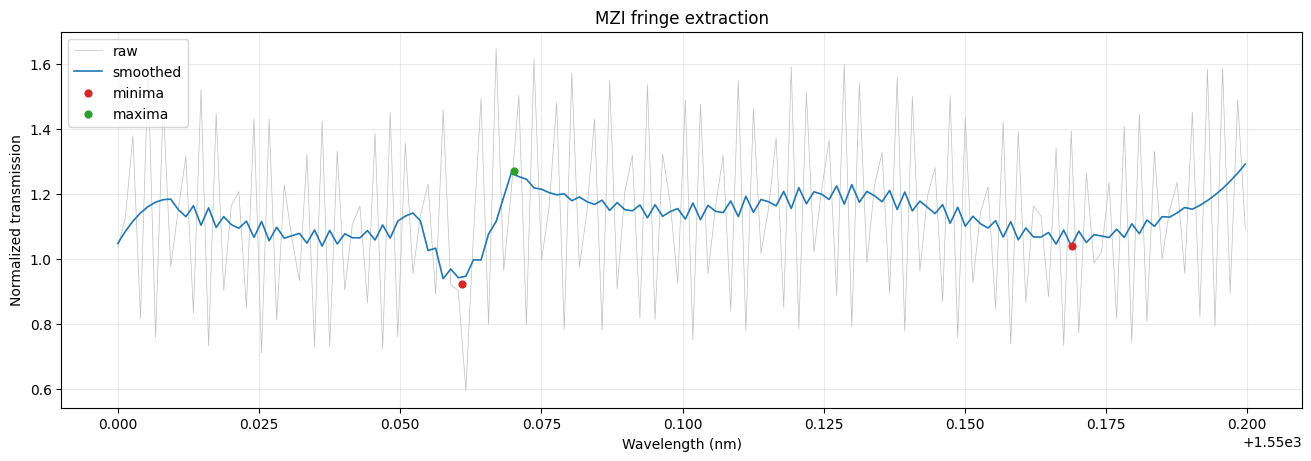

In [16]:
# Feature extraction settings. Adjust the range if the laser sweep has a noisy or clipped section.
ANALYSIS_START_NM = 1550.0
ANALYSIS_STOP_NM = 1550.2
SMOOTHING_WIDTH_NM = 0.02
MIN_FEATURE_SPACING_NM = 0.10
MIN_PROMINENCE = 0.05
GROUP_INDEX = 1.468  # Used only for the optional path-difference estimate below.

sample_spacing_nm = np.median(np.diff(wavelength_nm))
smoothing_samples = max(5, int(round(SMOOTHING_WIDTH_NM / sample_spacing_nm)))
if smoothing_samples % 2 == 0:
    smoothing_samples += 1
smoothing_samples = min(smoothing_samples, samples.size - 1 if samples.size % 2 == 0 else samples.size)

analysis_mask = (wavelength_nm >= ANALYSIS_START_NM) & (wavelength_nm <= ANALYSIS_STOP_NM)
analysis_wavelength_nm = wavelength_nm[analysis_mask]
analysis_transmission = transmission[analysis_mask]
smooth_transmission = savgol_filter(analysis_transmission, smoothing_samples, polyorder=2)
minimum_distance = max(1, int(round(MIN_FEATURE_SPACING_NM / sample_spacing_nm)))

# Prominence is relative to normalized transmission, so it remains meaningful across files.
dip_indices, dip_properties = find_peaks(
    -smooth_transmission,
    distance=minimum_distance,
    prominence=MIN_PROMINENCE,
)
peak_indices, peak_properties = find_peaks(
    smooth_transmission,
    distance=minimum_distance,
    prominence=MIN_PROMINENCE,
)

dip_wavelengths_nm = analysis_wavelength_nm[dip_indices]
peak_wavelengths_nm = analysis_wavelength_nm[peak_indices]
fsr_nm = np.diff(dip_wavelengths_nm)

print(f"Analysis range: {ANALYSIS_START_NM:.3f} to {ANALYSIS_STOP_NM:.3f} nm")
print(f"Smoothing window: {smoothing_samples:,} samples ({smoothing_samples * sample_spacing_nm:.5f} nm)")
print(f"Detected {len(dip_wavelengths_nm)} minima and {len(peak_wavelengths_nm)} maxima")
if fsr_nm.size:
    center_wavelength_nm = np.mean(dip_wavelengths_nm)
    median_fsr_nm = np.median(fsr_nm)
    path_difference_mm = (center_wavelength_nm * 1e-9) ** 2 / (GROUP_INDEX * median_fsr_nm * 1e-9) * 1e3
    print(f"Median FSR: {median_fsr_nm:.5f} nm")
    print(f"Estimated optical path difference for n_g={GROUP_INDEX:.3f}: {path_difference_mm:.3f} mm")
else:
    median_fsr_nm = np.nan
    print("No minima were detected; reduce MIN_PROMINENCE or MIN_FEATURE_SPACING_NM.")

fig, ax = plt.subplots(figsize=(13, 4.5), constrained_layout=True)
ax.plot(analysis_wavelength_nm[::plot_step], analysis_transmission[::plot_step], color="0.75", linewidth=0.5, label="raw")
ax.plot(analysis_wavelength_nm[::plot_step], smooth_transmission[::plot_step], color="tab:blue", linewidth=1.2, label="smoothed")
ax.scatter(dip_wavelengths_nm, smooth_transmission[dip_indices], color="tab:red", s=24, label="minima", zorder=3)
ax.scatter(peak_wavelengths_nm, smooth_transmission[peak_indices], color="tab:green", s=24, label="maxima", zorder=3)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized transmission")
ax.set_title("MZI fringe extraction")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

In [9]:
import pandas as pd

minima_table = pd.DataFrame({
    "wavelength_nm": dip_wavelengths_nm,
    "normalized_transmission": smooth_transmission[dip_indices],
    "prominence": dip_properties["prominences"],
})
minima_table["spacing_to_previous_nm"] = minima_table["wavelength_nm"].diff()

maxima_table = pd.DataFrame({
    "wavelength_nm": peak_wavelengths_nm,
    "normalized_transmission": smooth_transmission[peak_indices],
    "prominence": peak_properties["prominences"],
})

features_file = DATA_DIR / f"{DATA_FILE.stem}_fringe_features.csv"
minima_table.to_csv(features_file, index=False)

print("Detected minima:")
display(minima_table.round(6))
print("\nDetected maxima:")
display(maxima_table.round(6))
print(f"\nFeature table written to: {features_file}")

Detected minima:


,wavelength_nm,normalized_transmission,prominence,spacing_to_previous_nm
0,1558.387800,0.886136,1.002050,NaN
1,1558.800781,0.890655,1.009394,0.412981
2,1559.573801,0.894177,1.022506,0.773021
3,1561.213703,1.820847,0.071148,1.639901



Detected maxima:


,wavelength_nm,normalized_transmission,prominence
0,1558.266592,1.888186,0.952472
1,1558.564776,1.900049,1.009394
2,1559.121516,1.916683,1.022506
3,1560.447826,1.931275,0.874155
4,1561.854210,1.891996,0.071148



Feature table written to: C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\QTLab\RR Manual data\30cm_C1_fringe_features.csv
